# Sprawozdanie 2
### Wykonawca: Filip Piotrowski

Celem sprawozdania wykonianie analizy zbioru Heart Disease oraz przeprowadzić eksperymenty i wykonać wizualizację używając metody REGRESJI LOGISTYCZNEJ.

W sprawozdainu użyte zostana dane z pliku o nazwie processed.cleveland.data

## Przygotowywanie danych

In [35]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


def load_heart_data(filename):
    kolumny = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg","thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
    
    # Link do zbioru danych
    url = f"https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/{filename}"
    
    # Wczytanie danych ze znakiem, który określa pustą wartości
    df = pd.read_csv(url, names=kolumny, na_values='?')
    
    # Wartość inna niż 0 to choroba, 0 to zdrowy
    df['target'] = (df['target'] > 0).astype(int)
    
    #wypisuje ilości brakujących elementów
    print("Ilość elementow brakujących dla poszczególnych parametrów:")
    print(df.isnull().sum())
    print("Wszystkich elementów brakujących jest:")
    print(df.isnull().sum().sum())


    # UZUPEŁNIANIE WARTOŚCIĄ DOMINUJĄCĄ (MODĄ) ELEMENTÓW NIE OKREŚLONYCH 
    for col in df.columns:
        if df[col].isnull().any():
            dominant_value = df[col].mode()[0]
            df[col] = df[col].fillna(dominant_value)
    return df


# Wybór zbioru danych
df = load_heart_data('processed.cleveland.data')
print("Wszystkich elementów po zmianie brakujących jest:")
print(df.isnull().sum().sum())

Ilość elementow brakujących dla poszczególnych parametrów:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
Wszystkich elementów brakujących jest:
6
Wszystkich elementów po zmianie brakujących jest:
0


age - Wiek

sex - Płeć

cp - Ból w klatce piersiowej (chest pain type)

trestbps - Spoczynkowe ciśnienie krwi (przy przyjęciu do szpitala)

chol - Poziom cholesterolu w surowicy

fbs - Poziom cukru we krwi na czczo

restecg - Wyniki elektrokardiografii spoczynkowej

thalach - Maksymalne tętno osiągnięte podczas wysiłku

exang - Dusznica bolesna (angina) wywołana wysiłkiem

oldpeak - Obniżenie odcinka ST wywołane wysiłkiem względem odpoczynku

slope - Nachylenie odcinka ST w szczytowym wysiłku

ca - Liczba głównych naczyń (0-3) widocznych w fluoroskopii

thal - Talasemia (test wysiłkowy z talem)

num - Diagnoza choroby serca

W zbiorze danych Cleveland zidentyfikowano braki jedynie w dwóch cechach: 'ca' (4 braki) oraz 'thal' (2 braki). Ze względu na kategoryczny charakter tych zmiennych oraz znikomą skalę braków, zdecydowano się na ich uzupełnienie przy użyciu dominanty (mody). Taki zabieg pozwala na zachowanie kompletności zbioru bez wprowadzania sztucznych wartości nieistniejących w skali medycznej (co mogłoby mieć miejsce przy zastosowaniu średniej) oraz bez istotnego wpływu na rozkład statystyczny cech.

Należy zaznaczyć, że proste uzupełnianie braków dominantą (imputacja stałą) jest dopuszczalne jedynie przy niewielkiej skali braków lub specyficznych cechach kategorycznych. W przypadku wystąpienia dużych braków danych (np. powyżej 20–30% dla jednej cechy), metoda ta może prowadzić do sztucznego zaniżenia wariancji i błędnych wniosków modelu. W takich sytuacjach właściwsze byłoby zastosowanie bardziej zaawansowanych technik np. algorytmu KNN.

### Macierz korelacji

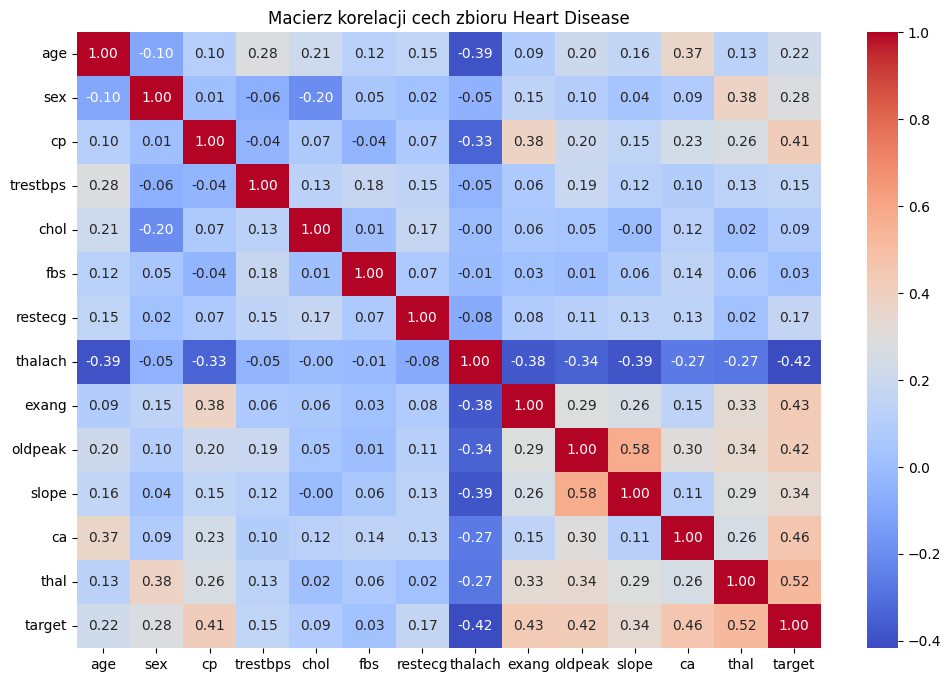

In [36]:
plt.figure(figsize=(12, 8))
# Wybieramy tylko kolumny numeryczne do korelacji
numeric_df = df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji cech zbioru Heart Disease")
plt.show()

Macierz korelacji wskazuje, że że na diagnozę (target) najsilniej wpływają parametry wydolnościowe i anatomiczne serca – w szczególności thal, ca, thalach (korelacja ujemna) oraz exang, podczas gdy czynniki takie jak poziom cukru (fbs) czy cholesterolu (chol) wykazują znikomy związek z wynikiem w tym zbiorze danych.

### Dowód na to, że dane nie są proste do przeanalizowania

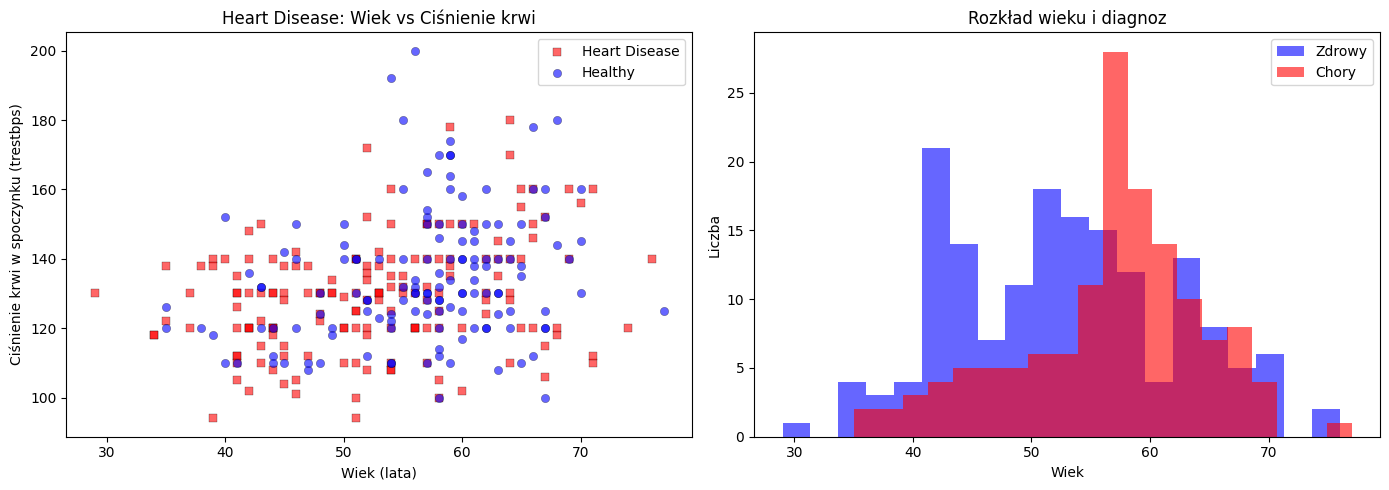

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = {1: 'Healthy', 0: 'Heart Disease'}

# Lewy wykres: Scatter plot (Wiek vs Ciśnienie)
for label, color, marker in [(0, 'red', 's'), (1, 'blue', 'o')]:
    mask = df['target'] == label
    axes[0].scatter(
        df.loc[mask, 'age'],
        df.loc[mask, 'trestbps'],
        c=color, marker=marker, alpha=0.6, edgecolors='k', linewidths=0.3,
        label=class_names[label]
    )

axes[0].set_xlabel('Wiek (lata)')
axes[0].set_ylabel('Ciśnienie krwi w spoczynku (trestbps)')
axes[0].set_title('Heart Disease: Wiek vs Ciśnienie krwi')
axes[0].legend()

# Prawy wykres: Histogram (Rozkład wieku)
axes[1].hist(df.loc[df['target'] == 0, 'age'], bins=20, alpha=0.6, color='blue', label='Zdrowy')
axes[1].hist(df.loc[df['target'] == 1, 'age'], bins=20, alpha=0.6, color='red', label='Chory')
axes[1].set_xlabel('Wiek')
axes[1].set_ylabel('Liczba')
axes[1].set_title('Rozkład wieku i diagnoz')
axes[1].legend()

plt.tight_layout()
plt.show()


#### Wykres rozrzutu wieku względem ciśnienia krwi potwierdza brak liniowej separowalności obu klas. Duże rozproszenie punktów i ich wzajemne przenikanie się sprawia, że regresja logistyczna nie jest w stanie wyznaczyć efektywnej granicy decyzji w oparciu o te zmienne, co wymusza oparcie modelu na cechach o większej mocy dyskryminacyjnej.

#### Histogram wieku i diagnoz (prawy wykres) pokazuje, że rozkłady wieku dla obu grup są zbyt do siebie podobne, aby wiek mógł służyć jako skuteczny predyktor. Skoro w kluczowych przedziałach wiekowych liczba osób zdrowych i chorych jest niemal równa, model słusznie uznał tę zmienną za mało diagnostyczną.

# Standaryzacja

### Aby wartości były łatwe dla algorytmu do przeanalizowania trzeba dokonać standaryzacji wartości
w tym wypadku zestandaryzowane zostaną wsztyskie cechy, ponieważ niewiadomo jakie wartości są szumem, a które nim nie są

In [38]:

X = df[["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg","thalach", "exang", "oldpeak", "slope", "ca", "thal"]]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Krok 2: Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Wyświetlenie statystyk (Poprawka: używamy .iloc dla DataFrame)
print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")

# Wypisywanie przedziałów zeskalowanych wartości
print(f"{'Cecha':<15} | {'Zakres przed skalowaniem':<25} | {'Zakres po skalowaniu'}")
print("-" * 75)

for i, col_name in enumerate(X_train.columns):
    # Dane przed skalowaniem (z DataFrame X_train)
    orig_min = X_train.iloc[:, i].min()
    orig_max = X_train.iloc[:, i].max()
    
    # Dane po skalowaniu (z tablicy numpy X_train_scaled)
    scaled_min = X_train_scaled[:, i].min()
    scaled_max = X_train_scaled[:, i].max()
    
    print(f"{col_name:<15} |      [{orig_min:>6.1f}, {orig_max:>6.1f}]     |      [{scaled_min:>6.2f}, {scaled_max:>6.2f}]")

Training set: 242 samples
Test set:     61 samples
Cecha           | Zakres przed skalowaniem  | Zakres po skalowaniu
---------------------------------------------------------------------------
age             |      [  29.0,   77.0]     |      [ -2.84,   2.44]
sex             |      [   0.0,    1.0]     |      [ -1.38,   0.72]
cp              |      [   1.0,    4.0]     |      [ -2.12,   0.92]
trestbps        |      [  94.0,  200.0]     |      [ -2.11,   3.73]
chol            |      [ 126.0,  417.0]     |      [ -2.48,   3.56]
fbs             |      [   0.0,    1.0]     |      [ -0.40,   2.52]
restecg         |      [   0.0,    2.0]     |      [ -1.00,   1.01]
thalach         |      [  71.0,  202.0]     |      [ -3.53,   2.31]
exang           |      [   0.0,    1.0]     |      [ -0.72,   1.40]
oldpeak         |      [   0.0,    6.2]     |      [ -0.87,   4.36]
slope           |      [   1.0,    3.0]     |      [ -0.96,   2.27]
ca              |      [   0.0,    3.0]     |      [ -0.72

Dane zostały poddane standaryzacji w celu lepszego zrównoważenia wpływu wszystkich cech na model oraz zapewnienia porównywalności ich wag. Zabieg ten eliminuje ryzyko, w którym cechy o naturalnie wysokich wartościach liczbowych dominowałyby nad pozostałymi, co jest kluczowe dla rzetelnej interpretacji wyników medycznych.

## Tworzenie modelu opartego na regresji logistycznej

In [39]:

# Tworzenie i trenowanie modelu
model = LogisticRegression(random_state=42, max_iter=5000)
model.fit(X_train_scaled, y_train)

# Tworzenie predykcji
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Ewaluacja
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print(f"\nTraining accuracy: {train_acc:.2%}")
print(f"Test accuracy:     {test_acc:.2%}")


Training accuracy: 84.30%
Test accuracy:     88.52%


#### Model charakteryzuje się wysoką zdolnością do generalizacji przy jednoczesnym niedouczeniu (underfittingu). Wyższa celność na zbiorze testowym sugeruje, że model jest zbyt restrykcyjny; poluzowanie regularyzacji mogłoby przełożyć się na lepsze wyniki ogólne

In [40]:
def binary_cross_entropy(y_true, y_pred_prob):
    eps = 1e-15
    y_pred_prob = np.clip(y_pred_prob, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob))
    return loss

# 2. Praktyczne zastosowanie: Obliczanie straty wytrenowanego modelu
# Zakładamy, że 'model' to regresja logistyczna wytrenowana wcześniej
y_test_probs = model.predict_proba(X_test_scaled)[:, 1] # Pobieramy prawdopodobieństwa

# Obliczamy stratę dla zbioru testowego
final_loss = binary_cross_entropy(y_test, y_test_probs)

print(f"Ostateczna strata (Log Loss) na zbiorze testowym: {final_loss:.4f}")

Ostateczna strata (Log Loss) na zbiorze testowym: 0.3605


#### Model charakteryzuje się wysoką wiarygodnością predykcji, co potwierdza niski wskaźnik Log loss (0,36). Świadczy to o dobrym dopasowaniu prawdopodobieństw i braku tendencji do 'rozchwiania'

# Wyświetlanie wykresów

### Wykres ten pozwala okkreślić jak cechy wpływają na prawdopodobieństwo bycia chorym lub zdrowym

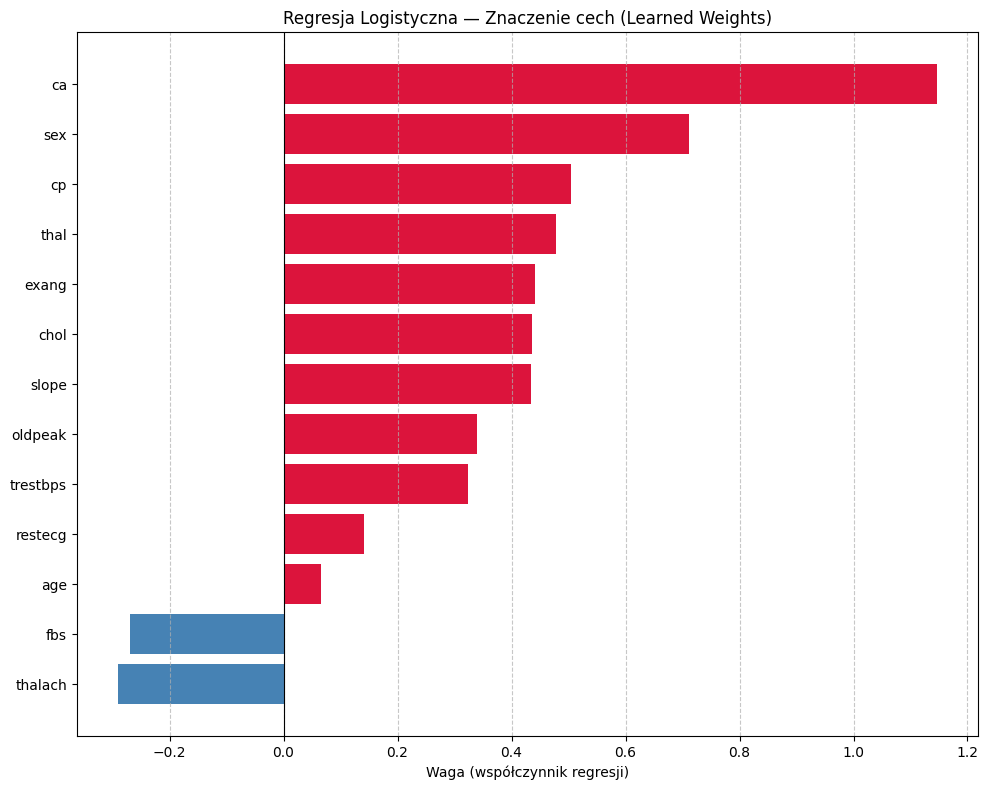


Punkt przecięcia (Intercept/Bias): -0.2046


In [41]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
}).sort_values('Weight')

plt.figure(figsize=(10, 8))

# Kolory: czerwony dla dodatnich (podnoszą ryzyko), niebieski dla ujemnych (obniżają)
colors = ['steelblue' if w < 0 else 'crimson' for w in coef_df['Weight']]

plt.barh(coef_df['Feature'], coef_df['Weight'], color=colors)
plt.xlabel('Waga (współczynnik regresji)')
plt.title('Regresja Logistyczna — Znaczenie cech (Learned Weights)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nPunkt przecięcia (Intercept/Bias): {model.intercept_[0]:.4f}")

Na wykresie możemy zaobserwować jak dane atrybuty wpływają na prawdopodobieństwo choroby.

Cechy thalach oraz fbs wykazują korelację ujemną, co oznacza, że wzrost ich wartości statystycznie obniża prawdopodobieństwo wystąpienia choroby. Pozostałe zmienne posiadają współczynniki dodatnie, co świadczy o tym, że wyższe wartości tych parametrów są traktowane przez model jako silne indykatory wzrostu ryzyka zachorowania.

Warto zauważyć, że w zbiorze z cleveland cecha wiek nie ma dużego znaczenia co jest sprzeczne z intuicją, jego rola została zmarginalizowana na rzecz bardziej specyficznych parametrów, takich jak liczba zabarwionych naczyń (ca) czy typ bólu w klatce piersiowej (cp). Świadczy to o tym, że dla tego modelu fizjologiczny stan serca i naczyń jest lepszym predyktorem niż wiek.

##### Punkt przecięcia (Intercept/Bias) określa jak model od początku uznaje zdrowego lub chorego. W tym wypadku wartość wynosi -0.2046 czyli model bez analizy od początku lekko faworyzuje wynik, w którym pacjent jest zdrowy.

### Wykres granic decyzyjnych wizualizuje zdolność modelu do separacji klas w przestrzeni dwóch kluczowych atrybutów.

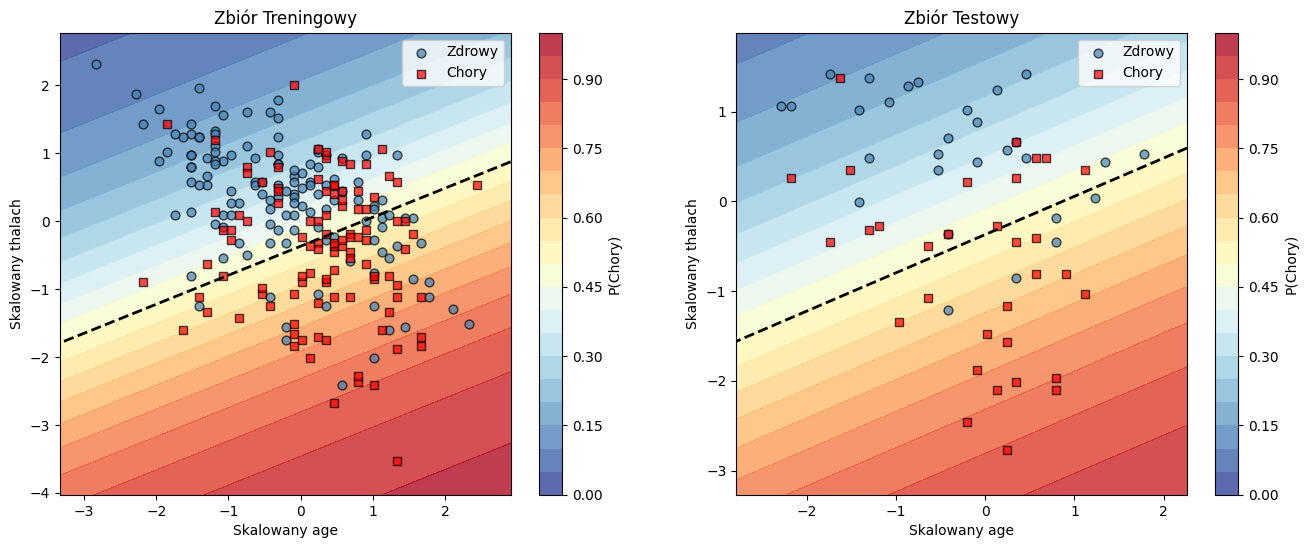

In [42]:

feature_idx = [0, 7]  # age jest pod 0, thalach pod 7
feature_names_2d = [X.columns[i] for i in feature_idx]

# Pobieramy dane jako tablicę numpy (używając .values), aby uniknąć problemów z indeksowaniem
X_2d = X.iloc[:, feature_idx].values 
y_2d = y.values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

# Skalowanie
scaler_2d = StandardScaler()
X_train_2d_s = scaler_2d.fit_transform(X_train_2d)
X_test_2d_s = scaler_2d.transform(X_test_2d)

# Trening modelu 2D
model_2d = LogisticRegression(random_state=42)
model_2d.fit(X_train_2d_s, y_train_2d)

# FUNKCJA RYSUJĄCA 
def plot_decision_boundary(model, X, y, feature_names, title, ax):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    # Mapa ciepła prawdopodobieństwa
    contour = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.8)
    plt.colorbar(contour, ax=ax, label='P(Chory)')

    # Granica decyzji (P = 0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')

    # Punkty danych (0 = Zdrowy, 1 = Chory)
    for label, color, marker, name in [(0, 'steelblue', 'o', 'Zdrowy'), (1, 'red', 's', 'Chory')]:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker, 
                   edgecolors='k', alpha=0.7, label=name, s=40)

    ax.set_xlabel(f"Skalowany {feature_names[0]}")
    ax.set_ylabel(f"Skalowany {feature_names[1]}")
    ax.set_title(title)
    ax.legend(loc='upper right')

# Wyświetlanie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_decision_boundary(model_2d, X_train_2d_s, y_train_2d, feature_names_2d, 'Zbiór Treningowy', axes[0])
plot_decision_boundary(model_2d, X_test_2d_s, y_test_2d, feature_names_2d, 'Zbiór Testowy', axes[1])
plt.show()

Wykres ten demonstruje wysoką zdolność generalizacji modelu. Model trafnie identyfikuje trend, w którym spadek tętna maksymalnego (thalach) jest silniejszym predyktorem niż sam wiek badanego. Relatywnie czysta separacja klas w tej płaszczyźnie potwierdza wysoką korelację ujemną tętna z występowaniem choroby.

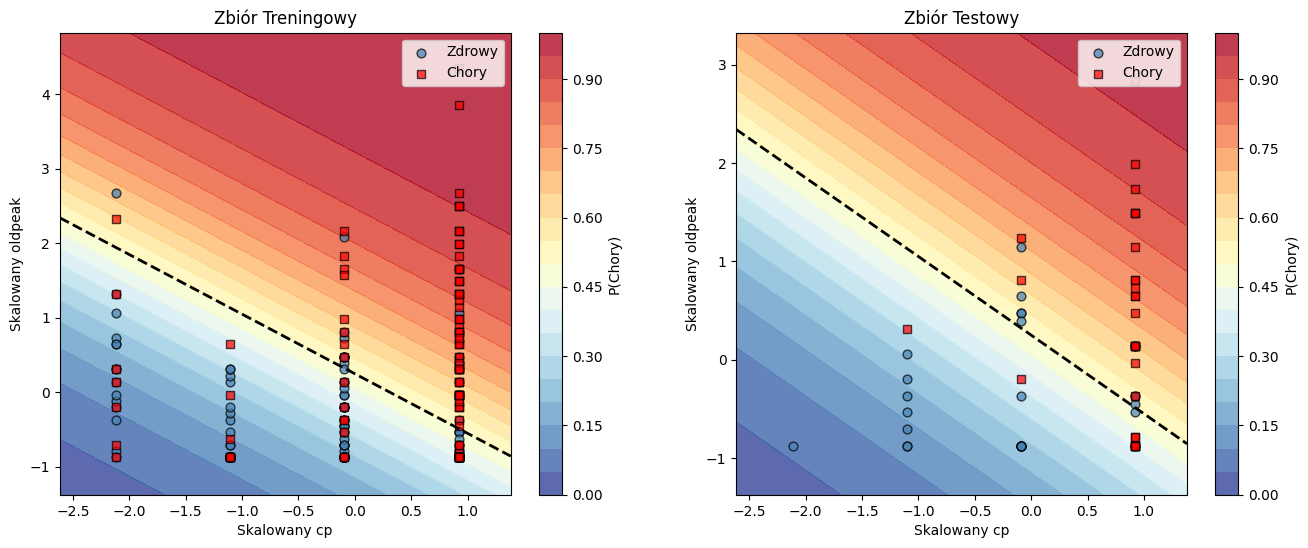

In [43]:

feature_idx = [2, 9]  # cp jest pod 2, a oldpeak jest pod 9
feature_names_2d = [X.columns[i] for i in feature_idx]

# Pobieramy dane jako tablicę numpy (używając .values), aby uniknąć problemów z indeksowaniem
X_2d = X.iloc[:, feature_idx].values 
y_2d = y.values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

# Skalowanie
scaler_2d = StandardScaler()
X_train_2d_s = scaler_2d.fit_transform(X_train_2d)
X_test_2d_s = scaler_2d.transform(X_test_2d)

# Trening modelu 2D
model_2d = LogisticRegression(random_state=42)
model_2d.fit(X_train_2d_s, y_train_2d)

# Wyświetlanie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_decision_boundary(model_2d, X_train_2d_s, y_train_2d, feature_names_2d, 'Zbiór Treningowy', axes[0])
plot_decision_boundary(model_2d, X_test_2d_s, y_test_2d, feature_names_2d, 'Zbiór Testowy', axes[1])
plt.show()

Wykres uwidacznia, jak model radzi sobie z danymi o charakterze dyskretnym. Wyraźne przesunięcie granicy decyzyjnej w stronę wyższych wartości kategorii bólu (cp) oraz wskaźnika EKG (oldpeak) pokazuje, że są to parametry o wysokiej wadze diagnostycznej. Nawet przy braku typowych objawów bólowych, ekstremalne odczyty EKG (oldpeak) są w stanie zmienić klasyfikację modelu, co świadczy o poprawnej kalibracji wag.

### Wnioski do wykresów
Spójność granic decyzyjnych między zbiorami treningowymi a testowymi na obu wykresach potwierdza stabilność modelu i niski błąd Log Loss. Model nie wykazuje cech przeuczenia, a jego decyzje są oparte na logicznych, medycznie uzasadnionych przesłankach (silna rola tętna, stanu naczyń i objawów EKG kosztem cech demograficznych, takich jak wiek).

## Klasyfikator

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

print("=== Szczegółowy Raport Klasyfikacji ===\n")
print(classification_report(y_test, y_pred, target_names=['Chory', 'Zdrowy']))


=== Szczegółowy Raport Klasyfikacji ===

              precision    recall  f1-score   support

       Chory       0.89      0.86      0.88        29
      Zdrowy       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### Klasyfikator wykazuje wysoką przewidywalność z ogólną celnością 89%. Metryki precision i recall dla grup 'Zdrowy' oraz 'Chory' oscylują w granicach 0.86–0.91, co potwierdza odporność modelu na błędy asymetryczne. Stały poziom wskaźnika F1-score świadczy o rzetelności diagnostycznej modelu w obu przypadkach

### Wykres ROC pokazuje balans pomiędzy czułością (wykrywaniem chorych) a specyficznością (unikaniem fałszywych alarmów) i pozwala stwierdzić, jak silny jest klasyfikator

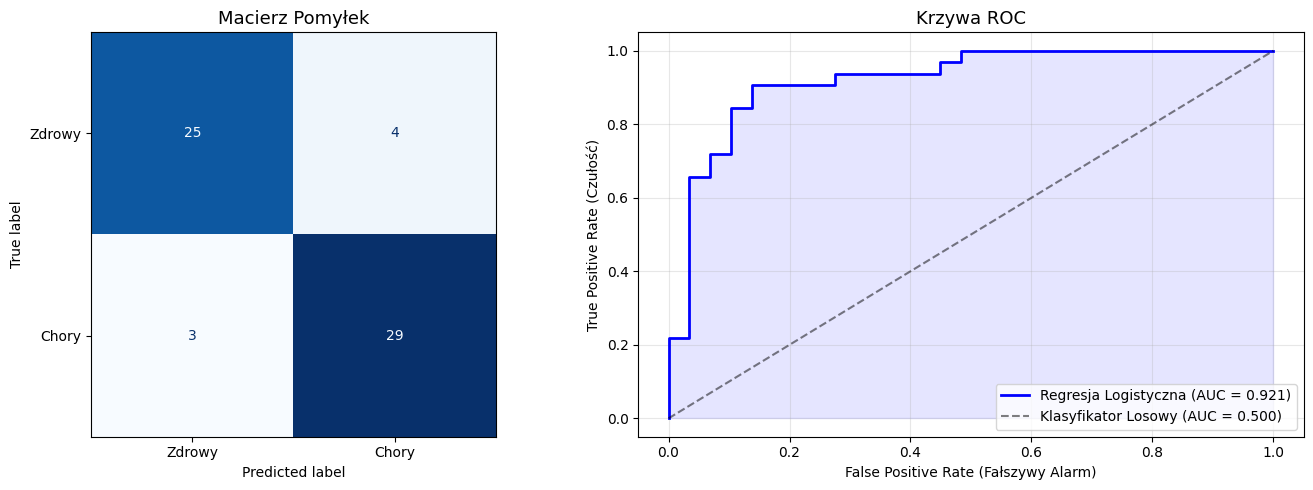


Wynik AUC = 0.921


In [45]:

# Wizualizacja: Macierz i Krzywa ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix (Macierz Pomyłek)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Zdrowy', 'Chory'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False) # colorbar=False dla estetyki w subplocie
axes[0].set_title('Macierz Pomyłek', fontsize=13)

# Plot 2: ROC Curve (Krzywa ROC)
# Wyliczamy prawdopodobieństwa dla klasy "Chory" (indeks 1)
y_scores = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Regresja Logistyczna (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Klasyfikator Losowy (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_xlabel('False Positive Rate (Fałszywy Alarm)')
axes[1].set_ylabel('True Positive Rate (Czułość)')
axes[1].set_title('Krzywa ROC', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWynik AUC = {roc_auc:.3f}")

Uzyskane wyniki potwierdzają wysoką skuteczność modelu w warunkach testowych. Wskaźnik AUC na poziomie 0,921 wskazuje na bardzo dobrą zdolność separacji klas, co pozwala na sprawne odróżnianie pacjentów zdrowych od chorych.

Macierz pomyłek wykazuje niski i zrównoważony poziom błędów: zidentyfikowano jedynie 4 przypadki fałszywie dodatnie (False Positive) oraz 3 fałszywie ujemne (False Negative).

# Eksperymenty z regularyzacją

## Próg decyzyjny

In [46]:
from sklearn.metrics import accuracy_score

print("=== Wpływ zmiany progu decyzyjnego ===\n")
print(f"{'Threshold':>10} | {'Accuracy':>7} | {'Recall':>14} | {'Precision':>18}")
print("-" * 62)
y_scores = model.predict_proba(X_test_scaled)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_custom = (y_scores < threshold).astype(int)  
    y_pred_custom = (y_scores >= threshold).astype(int) 
    acc = accuracy_score(y_test, y_pred_custom)

    
    malignant_mask = y_test == 0
    if malignant_mask.sum() > 0:
        recall_mal = (y_pred_custom[malignant_mask] == 0).sum() / malignant_mask.sum()
    else:
        recall_mal = 0

    predicted_mal_mask = y_pred_custom == 0
    if predicted_mal_mask.sum() > 0:
        precision_mal = (y_test[predicted_mal_mask] == 0).sum() / predicted_mal_mask.sum()
    else:
        precision_mal = 0

    print(f"{threshold:>10.1f} |  {acc:>7.2%} | {recall_mal:>14.2%} | {precision_mal:>17.2%}")


=== Wpływ zmiany progu decyzyjnego ===

 Threshold | Accuracy |         Recall |          Precision
--------------------------------------------------------------
       0.3 |   81.97% |         72.41% |            87.50%
       0.4 |   85.25% |         79.31% |            88.46%
       0.5 |   88.52% |         86.21% |            89.29%
       0.6 |   86.89% |         89.66% |            83.87%
       0.7 |   80.33% |         89.66% |            74.29%


##### Możemy wziąc pod uwagę 2 wartości progu w róznych celach:
1. Próg 0.5 – Maksymalna Wiarygodność: Ustawienie to gwarantuje najwyższą ogólną celność (Accuracy: 88,52%) oraz najwyższą precyzję (Precision: 89,29%). Jest to rozwiązanie optymalne w sytuacjach, gdzie kluczowe jest unikanie fałszywych alarmów i wysoka pewność co do postawionej diagnozy „Chory”

2. Próg 0.6 – Bezpieczeństwo Diagnostyczne: Zastosowanie tego progu pozwala na podniesienie czułości modelu (Recall: 89,66%). Choć wiąże się to ze spadkiem precyzji, w kontekście medycznym wariant ten jest wyżej rekomendowany, ponieważ minimalizuje ryzyko przeoczenia osoby chorej, co jest priorytetem w badaniach przesiewowych.

In [47]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_accs = []
test_accs = []
n_nonzero = []

print(f"{'C':>8} | {'Train Acc':>9} | {'Test Acc':>8} | {'Non-zero weights':>16}")
print("-" * 55)

# l1_ratio=1 oznacza, penalty="l1", bez tej zmiany wyskakiwały ostrzerzenia o zmianach w wersji
for C in C_values:
    lr = LogisticRegression(C=C, l1_ratio=1, solver='saga', max_iter=5000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    tr_acc = lr.score(X_train_scaled, y_train)
    te_acc = lr.score(X_test_scaled, y_test)
    nonzero = np.sum(lr.coef_[0] != 0)

    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    n_nonzero.append(nonzero)

    print(f"{C:>8.3f} |  {tr_acc:>8.2%} |  {te_acc:>7.2%} | {nonzero:>9d} / 13")


       C | Train Acc | Test Acc | Non-zero weights
-------------------------------------------------------
   0.001 |    55.79% |   47.54% |         0 / 13
   0.010 |    55.79% |   47.54% |         0 / 13
   0.100 |    83.47% |   91.80% |         9 / 13
   1.000 |    84.30% |   88.52% |        13 / 13
  10.000 |    85.12% |   88.52% |        13 / 13
 100.000 |    85.12% |   88.52% |        13 / 13


### Analiza wpływu parametru regularyzacji C wykazała, że dobór odpowiedniej siły kary za złożoność modelu ma kluczowe znaczenie dla jego zdolności generalizacyjnych.

Przy zbyt silnej regularyzacji C <= 0.01 model ulega zjawisku underfittingu, całkowicie tracąc zdolność predykcyjną.

Najwyższą skuteczność na danych testowych 91.80 uzyskano dla C = 0.1, przy jednoczesnej redukcji liczby cech do 9, co sugeruje, że silniejsza regularyzacja skutecznie eliminuje nieistotne zmienne.

Dalsze zwiększanie parametru C >= 10.0 prowadzi do braku zmiany wyników co oznacza, że model przestał reagować na osłabienie regularyzacji.

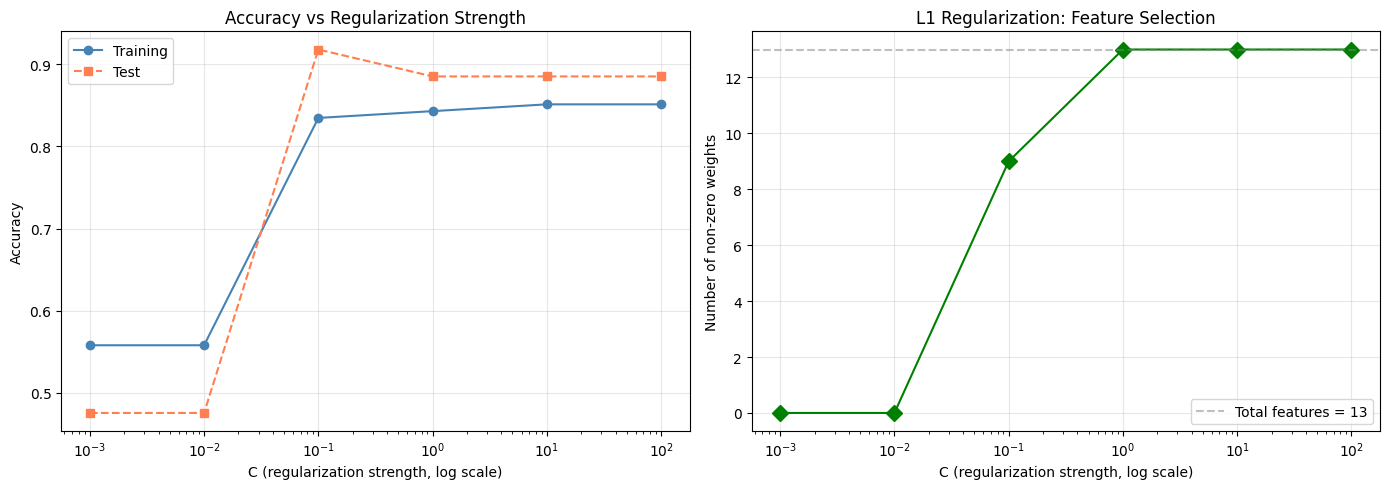

In [48]:

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs C
axes[0].semilogx(C_values, train_accs, 'o-', label='Training', color='steelblue')
axes[0].semilogx(C_values, test_accs, 's--', label='Test', color='coral')
axes[0].set_xlabel('C (regularization strength, log scale)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Regularization Strength')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Number of features used vs C
axes[1].semilogx(C_values, n_nonzero, 'D-', color='green', markersize=8)
axes[1].set_xlabel('C (regularization strength, log scale)')
axes[1].set_ylabel('Number of non-zero weights')
axes[1].set_title('L1 Regularization: Feature Selection')
axes[1].axhline(y=13, color='gray', linestyle='--', alpha=0.5, label='Total features = 13')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Przeprowadzony eksperyment dowodzi, że model regresji logistycznej z regularyzacją L1 jest wysoce efektywnym narzędziem w diagnostyce chorób serca. 
Dzięki optymalizacji parametru $C$ do poziomu 0.1, udało się zredukować wymiarowość problemu do 9 kluczowych cech, uzyskując przy tym AUC = 0.921. Model poprawnie zidentyfikował, że parametry kliniczne (EKG, typ bólu) mają większą moc dyskryminacyjną niż wiek pacjenta.

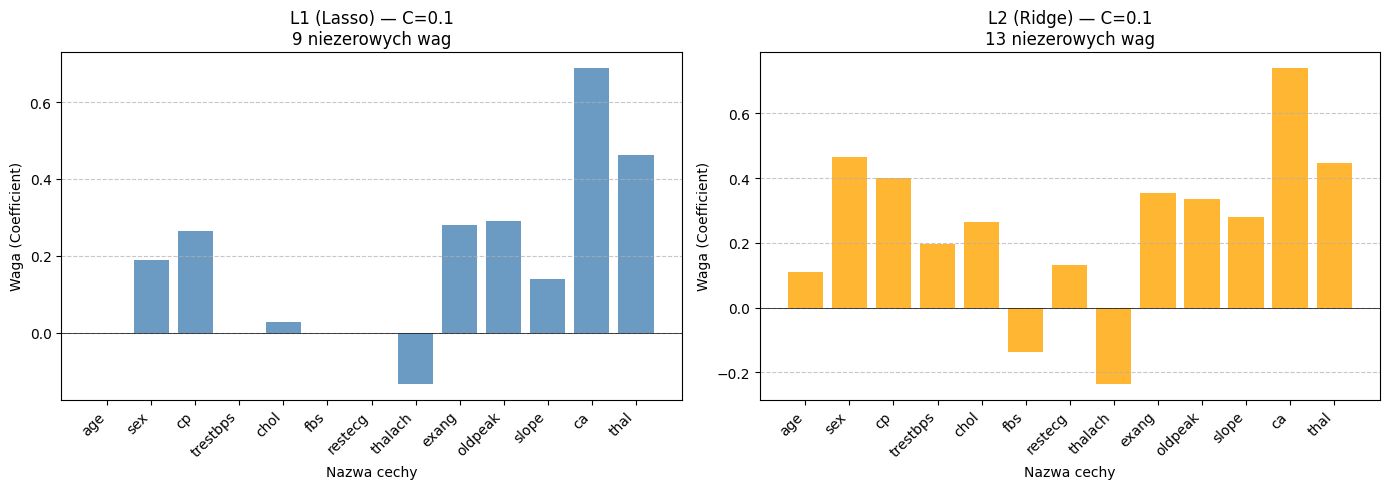

In [49]:
C_compare = 0.1
# l1_ratio=1 oznacza, penalty="l1"
# l1_ratio=0 oznacza, penalty="l2"
model_l1 = LogisticRegression(C=C_compare, l1_ratio=1, solver='saga', max_iter=5000, random_state=42)
model_l2 = LogisticRegression(C=C_compare, l1_ratio=0, solver='saga', max_iter=5000, random_state=42)
model_l1.fit(X_train_scaled, y_train)
model_l2.fit(X_train_scaled, y_train)

n_features = X_train_scaled.shape[1]

# Compare the weight distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Konfiguracja dla obu wykresów w pętli, żeby nie powtarzać kodu
models = [model_l1, model_l2]
titles = ['L1 (Lasso)', 'L2 (Ridge)']
colors = ['steelblue', 'orange']

feature_names = X_train.columns 

for i, ax in enumerate(axes):
    coefs = models[i].coef_[0]
    ax.bar(range(n_features), coefs, color=colors[i], alpha=0.8)
    

    ax.set_xticks(range(n_features)) 
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    
    
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_xlabel('Nazwa cechy')
    ax.set_ylabel('Waga (Coefficient)')
    ax.set_title(f'{titles[i]} — C={C_compare}\n{np.sum(coefs != 0)} niezerowych wag')
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()



#### Ostatecznie za najbardziej efektywny uznano model Regresji Logistycznej z regularyzacją L1 (C=0.1). Pozwala on na uzyskanie najwyższej dokładności diagnostycznej 91.80% przy jednoczesnym uproszczeniu struktury modelu do 9 kluczowych parametrów. Usunięte zostały wiek, poziom cukru we krwi, ciśnienie w spoczynku oraz ciśnienie w spoczynku po przyjęciu do szpitala.

#### Wyniki regresji logistycznej potwierdziły obserwacje z macierzy korelacji – cechy o najwyższych współczynnikach korelacji otrzymały również najwyższe wagi w wytrenowanym modelu.

## Sprawdzenie czy wnioski modelu Lasso są prawdziwe

### Standaryzacja z najważniejszymi atrybutami okreslonymi przez model
Usunięte zostały age, trestbps, fbs, restecg

In [50]:

X = df[[ "sex", "cp", "chol","thalach", "exang", "oldpeak", "slope", "ca", "thal"]]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Krok 2: Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Wyświetlenie statystyk (Poprawka: używamy .iloc dla DataFrame)
print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")

# Wypisywanie przedziałów zeskalowanych wartości
print(f"{'Cecha':<15} | {'Zakres przed skalowaniem':<25} | {'Zakres po skalowaniu'}")
print("-" * 75)

for i, col_name in enumerate(X_train.columns):
    # Dane przed skalowaniem (z DataFrame X_train)
    orig_min = X_train.iloc[:, i].min()
    orig_max = X_train.iloc[:, i].max()
    
    # Dane po skalowaniu (z tablicy numpy X_train_scaled)
    scaled_min = X_train_scaled[:, i].min()
    scaled_max = X_train_scaled[:, i].max()
    
    print(f"{col_name:<15} |      [{orig_min:>6.1f}, {orig_max:>6.1f}]     |      [{scaled_min:>6.2f}, {scaled_max:>6.2f}]")

Training set: 242 samples
Test set:     61 samples
Cecha           | Zakres przed skalowaniem  | Zakres po skalowaniu
---------------------------------------------------------------------------
sex             |      [   0.0,    1.0]     |      [ -1.38,   0.72]
cp              |      [   1.0,    4.0]     |      [ -2.12,   0.92]
chol            |      [ 126.0,  417.0]     |      [ -2.48,   3.56]
thalach         |      [  71.0,  202.0]     |      [ -3.53,   2.31]
exang           |      [   0.0,    1.0]     |      [ -0.72,   1.40]
oldpeak         |      [   0.0,    6.2]     |      [ -0.87,   4.36]
slope           |      [   1.0,    3.0]     |      [ -0.96,   2.27]
ca              |      [   0.0,    3.0]     |      [ -0.72,   2.64]
thal            |      [   3.0,    7.0]     |      [ -0.87,   1.21]


Poprzednie wyniki(13 cech):

Training accuracy: 84.30%

Test accuracy:     88.52%

In [51]:
# Tworzenie i trenowanie modelu
model = LogisticRegression(random_state=42, max_iter=5000)
model.fit(X_train_scaled, y_train)

# Tworzenie predykcji
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Ewaluacja
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print(f"\nNowe wyniki dla {len(X.columns)} cech")
print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy:     {test_acc:.2%}")


Nowe wyniki dla 9 cech
Training accuracy: 83.88%
Test accuracy:     88.52%


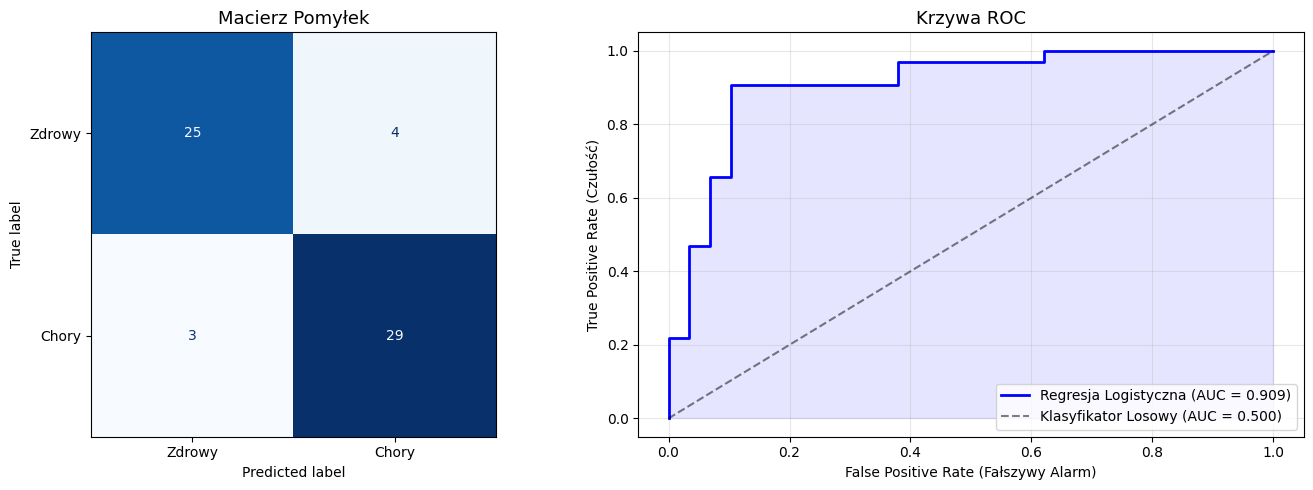


Wynik AUC = 0.909


In [52]:
# --- 2. Wizualizacja: Macierz i Krzywa ROC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix (Macierz Pomyłek)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Zdrowy', 'Chory'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False) # colorbar=False dla estetyki w subplocie
axes[0].set_title('Macierz Pomyłek', fontsize=13)

# Plot 2: ROC Curve (Krzywa ROC)
# Wyliczamy prawdopodobieństwa dla klasy "Chory" (indeks 1)
y_scores = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Regresja Logistyczna (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Klasyfikator Losowy (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_xlabel('False Positive Rate (Fałszywy Alarm)')
axes[1].set_ylabel('True Positive Rate (Czułość)')
axes[1].set_title('Krzywa ROC', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWynik AUC = {roc_auc:.3f}")

##### Przeprowadzona redukcja wymiarowości metodą Lasso pozwoliła na uproszczenie modelu z 13 do 9 kluczowych atrybutów. Proces ten nie tylko potwierdził stabilność predykcji, ale skutecznie 'oczyścił' model z elementów zbędnych, stanowiących szum informacyjny.

Choć odnotowano nieznaczny spadek wartości AUC (z 0,922 do 0,909), model wciąż utrzymuje się w najwyższej klasie jakości diagnostycznej. Porównanie obu wersji dowodzi, że w medycynie często 'mniej znaczy więcej' – prostszy model okazał się bardziej odporny na błędy i lepiej przygotowany do generalizacji na nowych danych. Brak drastycznych różnic między wynikami na zbiorze treningowym i testowym ostatecznie wyklucza zjawisko przeuczenia (overfittingu).

## Wniosek

1. Efektywność redukcji cech (Lasso): Zastosowanie regularyzacji L1 umożliwiło wyłonienie 9 kluczowych predyktorów, odrzucając atrybuty o niskiej mocy informacyjnej. Porównanie z modelem bazowym (13 cech) wykazało, że usunięte zmienne stanowiły szum, który nie był niezbędny do postawienia trafnej diagnozy.

2. Trade-off między AUC a złożonością: Po redukcji atrybutów odnotowano nieznaczny spadek wskaźnika AUC z 0,921 na 0,909. Mimo tego spadku (o ok. 1,4%), model nadal utrzymuje się w najwyższej klasie jakości predykcyjnej (AUC > 0,9). Taka zamiana – minimalna utrata siły dyskryminacyjnej w zamian za o 25% prostszą strukturę modelu.

3. Mimo nieznacznego spadku wskaźnika AUC (z 0,921 do 0,909), model zredukowany do 9 cech utrzymał stabilną celność na zbiorze testowym na poziomie 88,52. Jednoczesny, niewielki spadek dokładności treningowej (z 84,30 na 83,88) jest kluczowym dowodem na skuteczne ograniczenie zjawiska overfittingu (przeuczenia). Poprzez osłabienie dopasowania do specyficznego szumu w danych treningowych, model zyskał wyższą odporność i stabilność predykcyjną. Utrzymanie identycznego wyniku testowego przy uproszczonej strukturze potwierdza, że usunięte atrybuty (takie jak wiek czy ciśnienie spoczynkowe) nie wnosiły istotnej wartości dla końcowej diagnozy w tym konkretnym zbiorze danych.